# 🏥 Week 2: Exploratory Data Analysis (EDA) & Biomarker Correlation
**Author:** Krishnaveni Mitukula 

**Phase:** Clinical Data Visualization

## DAY 1: Setup & Univariate Analysis
**Objective:** Load the cleaned (unscaled) clinical dataset from Week 1. We use the unscaled data for EDA so our charts display interpretable, real-world medical values (e.g., Age 55, rather than a Z-score of -0.2). Today, we establish our visualization theme and analyze the baseline age distribution of our patient cohort.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
# 1. Load the CLEANED (unscaled) dataset so our charts show real numbers!
df = pd.read_csv('data/cleaned_heart_disease_data.csv')
print("Clean dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")
# Set a professional visual style for all our charts
sns.set_theme(style="whitegrid", palette="muted")


Clean dataset loaded successfully!
Dataset shape: (303, 15)


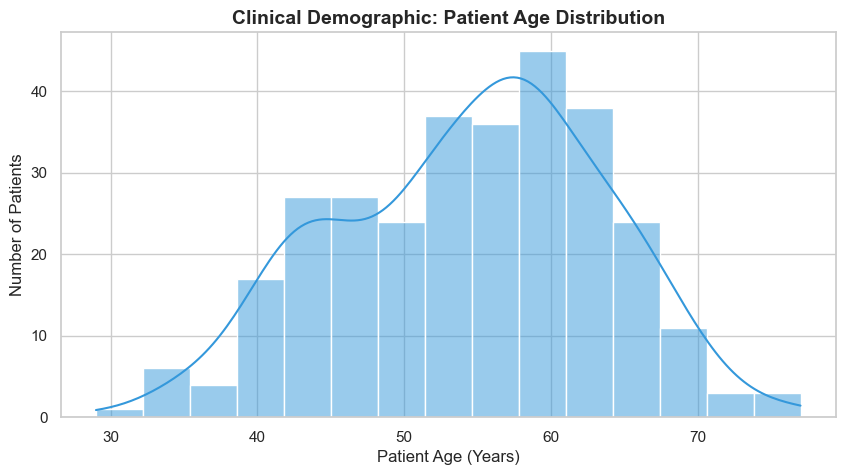

In [3]:
# 2. Univariate Analysis: Age Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['age'], bins=15, kde=True, color='#3498DB')
plt.title('Clinical Demographic: Patient Age Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Patient Age (Years)', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()

**Clinical Observation - Age Distribution:** 
The histogram indicates that the patient cohort is primarily composed of middle-aged to senior individuals. The distribution peaks around 58-60 years of age, with a significant concentration of patients between 50 and 65. This aligns with clinical expectations, as cardiovascular disease risk increases with age.


## DAY 2: Bivariate Analysis (Disease vs. Gender)
**Objective:** Compare patient gender against the target diagnosis. To make the visualization clinically readable, we will temporarily map our binary numeric codes (`0/1`) to their actual categorical text labels (`Female/Male` and `Healthy/Heart Disease`) strictly for plotting purposes.

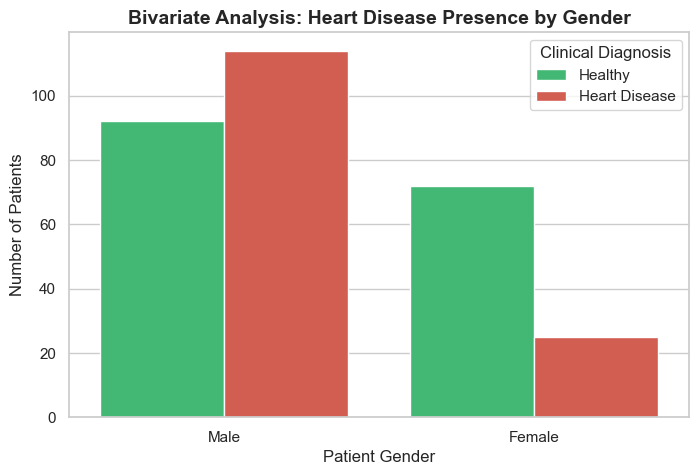

In [4]:
# 1. Create a temporary dataframe just for plotting so we get readable labels
plot_df = df.copy()
plot_df['sex'] = plot_df['sex'].map({0.0: 'Female', 1.0: 'Male'})
plot_df['target'] = plot_df['target'].map({0: 'Healthy', 1: 'Heart Disease'})
# 2. Bivariate Analysis: Grouped Bar Chart
plt.figure(figsize=(8, 5))
sns.countplot(data=plot_df, x='sex', hue='target', palette=['#2ECC71', '#E74C3C'])
plt.title('Bivariate Analysis: Heart Disease Presence by Gender', fontsize=14, fontweight='bold')
plt.xlabel('Patient Gender', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Clinical Diagnosis')
plt.show()

**Clinical Observation - Gender Risk:** 
The grouped bar chart reveals a significant gender disparity. While the dataset contains more males overall, females in this specific cohort show a disproportionately higher ratio of 'Heart Disease' to 'Healthy' compared to males. Males have a larger absolute number of healthy patients than diseased patients. 


## DAY 3: Symptom Analysis (Chest Pain Type)
**Objective:** Analyze the relationship between the four distinct types of chest pain and the presence of heart disease. 

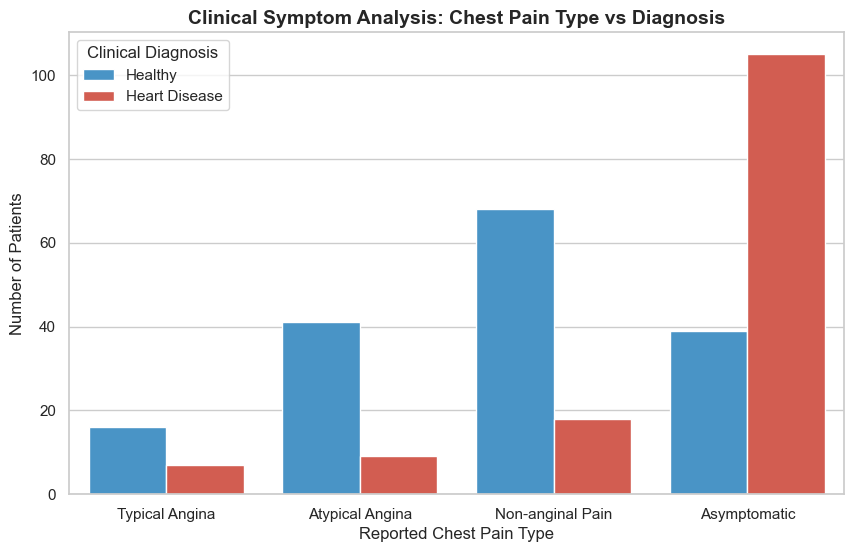

In [7]:

# 1. Map medical terminology for the plot
plot_df_cp = df.copy()
cp_mapping = {
    1.0: 'Typical Angina', 
    2.0: 'Atypical Angina', 
    3.0: 'Non-anginal Pain', 
    4.0: 'Asymptomatic'
}
plot_df_cp['cp'] = plot_df_cp['cp'].map(cp_mapping)
plot_df_cp['target'] = plot_df_cp['target'].map({0: 'Healthy', 1: 'Heart Disease'})

# 2. Bivariate Analysis: Grouped Bar Chart
plt.figure(figsize=(10, 6))
sns.countplot(
    data=plot_df_cp, 
    x='cp', 
    hue='target', 
    palette=['#3498DB', '#E74C3C'], 
    order=['Typical Angina', 'Atypical Angina', 'Non-anginal Pain', 'Asymptomatic']
)
plt.title('Clinical Symptom Analysis: Chest Pain Type vs Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Reported Chest Pain Type', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Clinical Diagnosis')
plt.show()


**Clinical Observation - Chest Pain:** 
Counter-intuitively, the highest prevalence of confirmed heart disease is found in patients presenting with 'Asymptomatic' chest pain (Type 4). Patients with 'Typical Angina' (classic heart pain) are overwhelmingly diagnosed as healthy in this cohort. This highlights the danger of "silent" heart disease and proves that severe chest pain does not immediately guarantee a positive disease diagnosis.


## DAY 4: Multivariate Analysis (Biomarker Correlation)
**Objective:** Generate a Pearson Correlation Heatmap for all continuous clinical biomarkers (Age, Blood Pressure, Cholesterol, Heart Rate, and ST Depression). This allows us to identify multicollinearity (where two features are highly correlated and redundant).

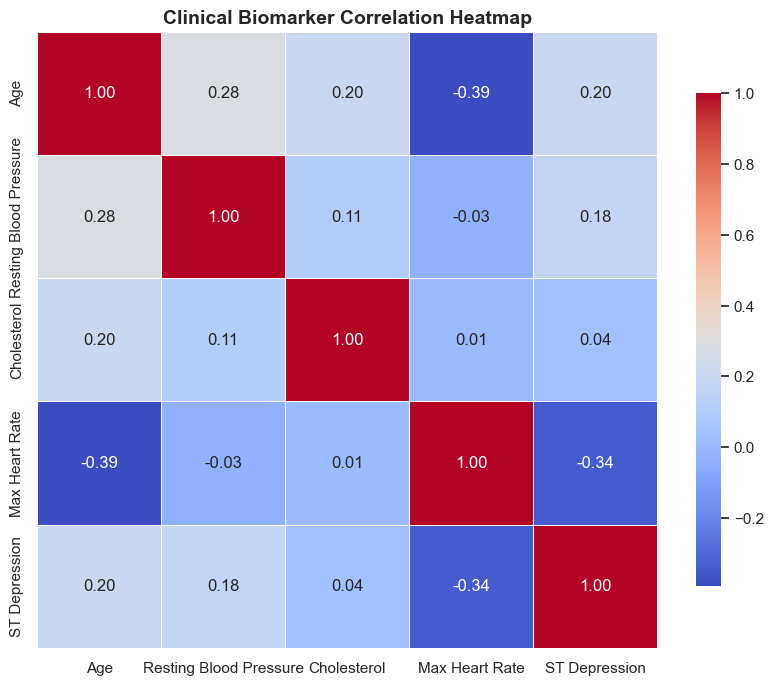

In [9]:

# 1. Isolate the continuous medical biomarkers
biomarkers = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# 2. Rename them to readable English JUST for this plot
rename_dict = {
    'age': 'Age',
    'trestbps': 'Resting Blood Pressure',
    'chol': 'Cholesterol',
    'thalach': 'Max Heart Rate',
    'oldpeak': 'ST Depression'
}
# 3. Calculate the mathematical correlation between them
corr_matrix = df[biomarkers].rename(columns=rename_dict).corr()
# 4. Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix, 
    annot=True,          # Show the exact numbers
    cmap='coolwarm',     # Red = Positive Correlation, Blue = Negative
    fmt='.2f',           # Show 2 decimal places
    linewidths=0.5, 
    cbar_kws={"shrink": .8}
)
plt.title('Clinical Biomarker Correlation Heatmap', fontsize=14, fontweight='bold')
plt.show()


**Clinical Observation - Biomarker Correlation:** 
Overall, there is very low multicollinearity among the continuous variables, meaning we do not need to drop any features for our ML model. The strongest relationship is a negative correlation (-0.40) between `age` and `thalach` (Max Heart Rate). This makes perfect physiological sense: as a patient's age increases, their maximum achievable heart rate naturally decreases.


## DAY 5: Biomarker Distributions across Patient Cohorts
**Objective:** As per the project requirements, we will plot the distribution of clinical biomarkers (Age vs. Max Heart Rate, and Cholesterol levels) across the healthy and diseased patient cohorts to identify clear physiological dividing lines between the two groups.


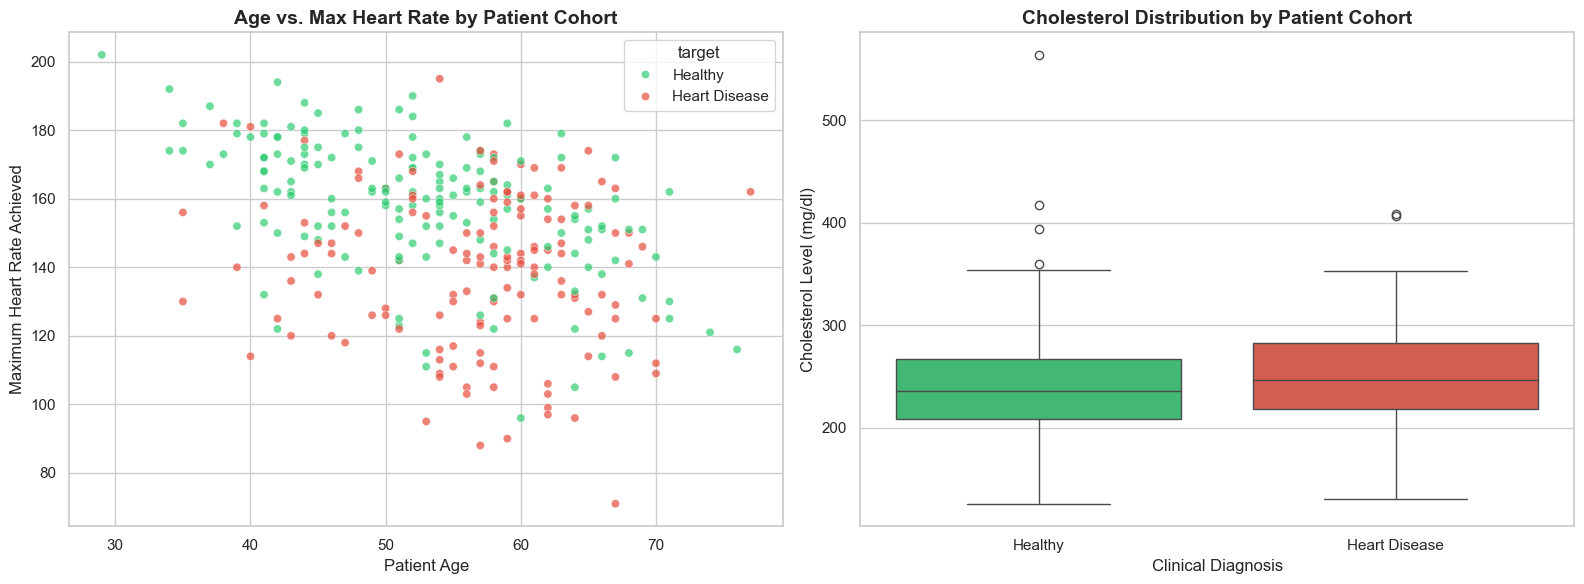

In [10]:


# Map target to text again for readable legends
plot_df = df.copy()
plot_df['target'] = plot_df['target'].map({0: 'Healthy', 1: 'Heart Disease'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Chart 1: Age vs Heart Rate across Cohorts (Scatterplot)
sns.scatterplot(data=plot_df, x='age', y='thalach', hue='target', alpha=0.7, palette=['#2ECC71', '#E74C3C'], ax=axes[0])
axes[0].set_title('Age vs. Max Heart Rate by Patient Cohort', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Patient Age', fontsize=12)
axes[0].set_ylabel('Maximum Heart Rate Achieved', fontsize=12)

# Chart 2: Cholesterol levels across Cohorts (Boxplot)
sns.boxplot(data=plot_df, x='target', y='chol', palette=['#2ECC71', '#E74C3C'], ax=axes[1])
axes[1].set_title('Cholesterol Distribution by Patient Cohort', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Clinical Diagnosis', fontsize=12)
axes[1].set_ylabel('Cholesterol Level (mg/dl)', fontsize=12)

plt.tight_layout()
plt.show()


**Clinical Observation - Biomarker Cohorts:** 
1. **Age vs Heart Rate:** Diseased patients (red) tend to cluster slightly lower on the Max Heart Rate axis compared to healthy patients, especially in older age groups. 
2. **Cholesterol:** Surprisingly, the median cholesterol for healthy patients and diseased patients is nearly identical. This indicates that cholesterol alone is NOT a strong enough predictor for heart disease in this specific dataset, and a multivariate Machine Learning model is definitely required.
